In [24]:
# ==========================================
# 1. REQUIRED LIBRARIES & IMPORT
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configure plot styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [25]:
# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv('employee_attrition_350.csv')
print("Dataset Loaded Successfully. Shape:", df.shape)



Dataset Loaded Successfully. Shape: (350, 11)


In [26]:
# ==========================================
# 3. BASIC EXPLORATION
# ==========================================
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Summary Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Summary Statistics (Numerical Features) ---")
print(df.describe())




--- First 5 Rows ---
   Age Department             JobRole  MonthlyIncome  DistanceFromHome  \
0   56      Sales           Executive          49915                 3   
1   46        R&D          Technician          47219                10   
2   32         HR  Research Scientist          90879                 2   
3   25         HR  Research Scientist          74644                27   
4   38         HR             Manager          70279                23   

   YearsAtCompany  JobSatisfaction  WorkLifeBalance OverTime  \
0               7                2                4       No   
1              14                4                3       No   
2              13                3                2      Yes   
3              17                3                1       No   
4              19                1                2       No   

   NumCompaniesWorked Attrition  
0                   8       Yes  
1                   0        No  
2                   1        No  
3           

In [27]:

# ==========================================
# 4. ATTRITION COUNT & DISTRIBUTION
# ==========================================
print("\n--- Attrition Count ---")
print(df['Attrition'].value_counts())

print("\n--- Attrition Percentage ---")
print(df['Attrition'].value_counts(normalize=True) * 100)




--- Attrition Count ---
Attrition
Yes    182
No     168
Name: count, dtype: int64

--- Attrition Percentage ---
Attrition
Yes    52.0
No     48.0
Name: proportion, dtype: float64


In [28]:

# ==========================================
# 5. DATA PREPROCESSING
# ==========================================
# Binary mapping for target column
y = df['Attrition'].map({'Yes': 1, 'No': 0})

# Features dataframe
X = df.drop('Attrition', axis=1)

# One-Hot Encoding for categorical predictors (OverTime, Department, JobRole)
X = pd.get_dummies(X, drop_first=True)

print("\nEngineered Feature Matrix Shape:", X.shape)



Engineered Feature Matrix Shape: (350, 14)


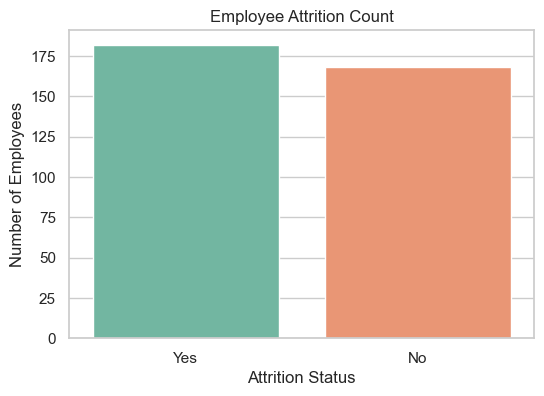

In [29]:
# ==========================================
# 6. VISUALIZATIONS & CORRELATION HEATMAP
# ==========================================
# Plot 1: Attrition Count Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='Set2', legend=False)
plt.title('Employee Attrition Count')
plt.xlabel('Attrition Status')
plt.ylabel('Number of Employees')
plt.show()


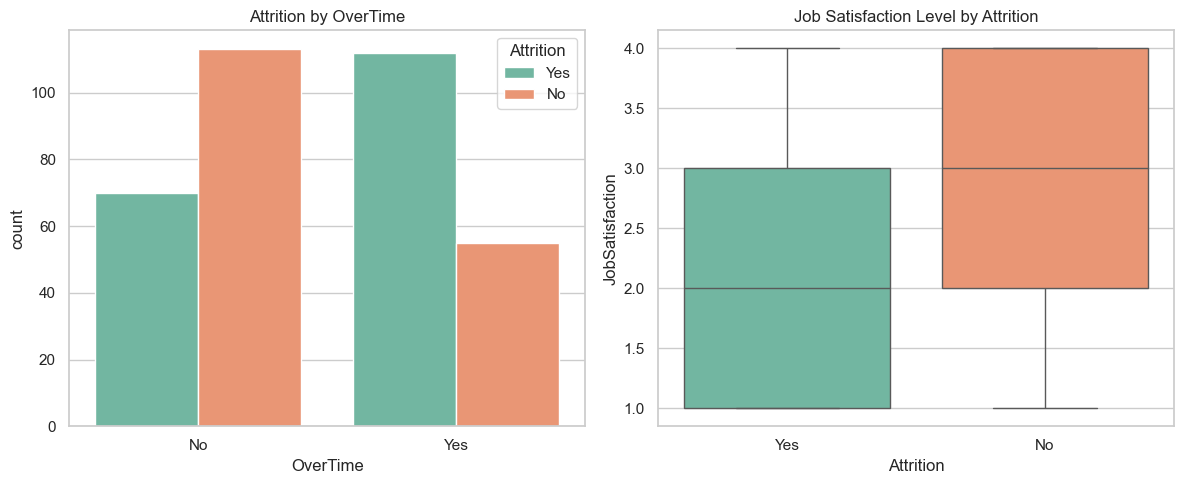

In [30]:
# Plot 2: Categorical Relationships (OverTime & Job Satisfaction)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set2')
plt.title('Attrition by OverTime')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Attrition', y='JobSatisfaction', hue='Attrition', palette='Set2', legend=False)
plt.title('Job Satisfaction Level by Attrition')

plt.tight_layout()
plt.show()


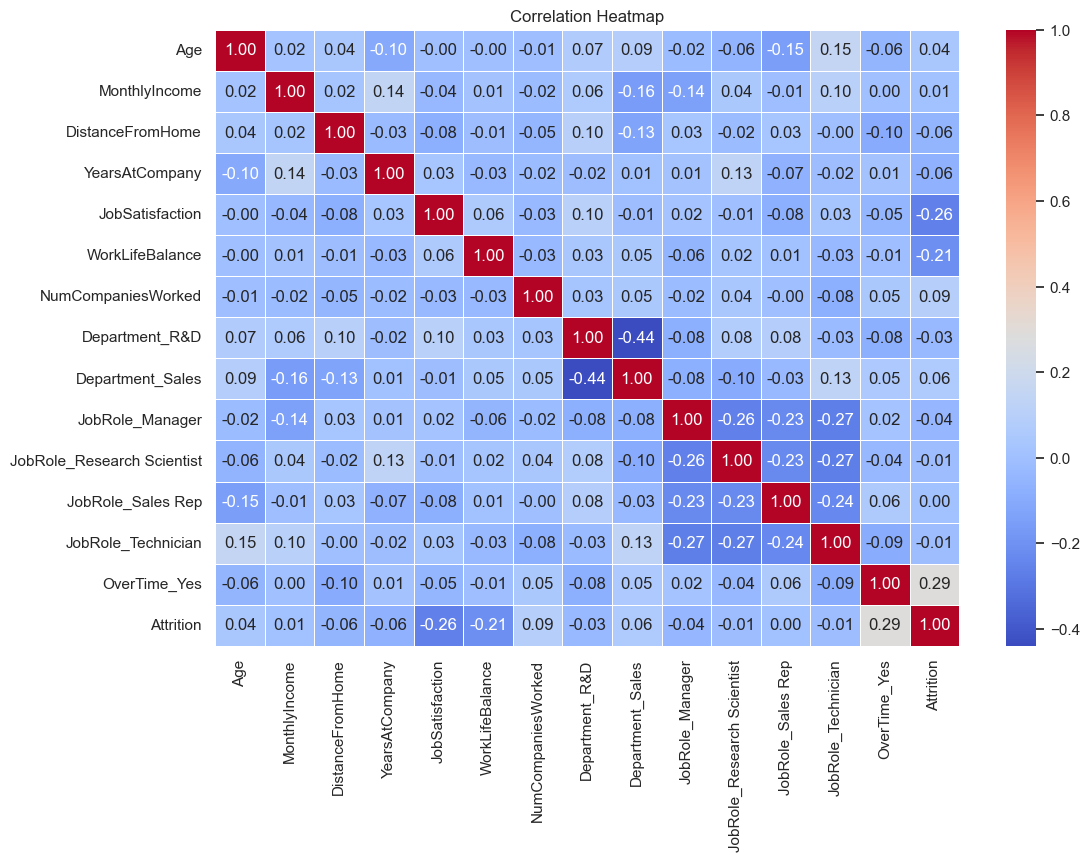

In [31]:
# Plot 3: Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = pd.concat([X, y], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



In [32]:

# ==========================================
# 7. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")



Training set size: 280 rows
Testing set size: 70 rows


In [33]:

# ==========================================
# 8. FEATURE SCALING
# ==========================================
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
# ==========================================
# 9. TRAIN MODEL
# ==========================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print("\nRandom Forest Classifier trained successfully.")




Random Forest Classifier trained successfully.


In [35]:

# ==========================================
# 10. PREDICTION
# ==========================================
y_pred = model.predict(X_test_scaled)


In [36]:
# ==========================================
# 11. MODEL EVALUATION & FEATURE IMPORTANCE
# ==========================================
print("\n--- Accuracy Score ---")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))



--- Accuracy Score ---
Model Accuracy: 58.57%

--- Confusion Matrix ---
[[18 16]
 [13 23]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.58      0.53      0.55        34
           1       0.59      0.64      0.61        36

    accuracy                           0.59        70
   macro avg       0.59      0.58      0.58        70
weighted avg       0.59      0.59      0.58        70



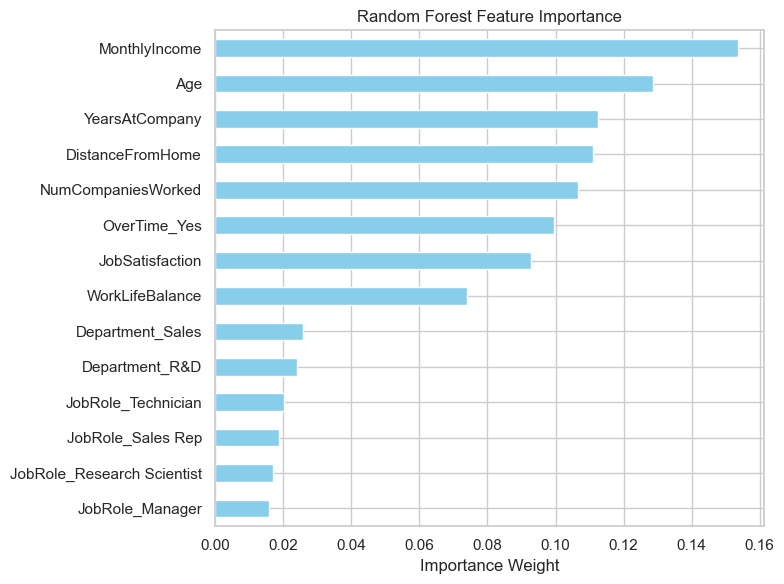

In [37]:
# Plot Feature Importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
feature_importances.plot(kind='barh', color='skyblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Weight')
plt.tight_layout()
plt.show()

In [38]:
# ==========================================
# 12. MULTI-MODEL COMPARISON
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Initialize multiple classification algorithms
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}
# Training and cross-evaluation loop
results = []
for name, model_obj in models.items():
    model_obj.fit(X_train_scaled, y_train)
    preds = model_obj.predict(X_test_scaled)
    probs = model_obj.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

comparison_df = pd.DataFrame(results)
print("\n--- Model Comparison Summary ---")
print(comparison_df.round(4))




--- Model Comparison Summary ---
                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
0  Logistic Regression    0.5286     0.5405  0.5556    0.5479   0.5997
1        Decision Tree    0.5000     0.5135  0.5278    0.5205   0.4992
2        Random Forest    0.5857     0.5897  0.6389    0.6133   0.6127


In [43]:

# ==========================================
# 13. HYPERPARAMETER TUNING (GRIDSEARCHCV)
# ==========================================
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define parameter grid for tuning Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8, None],
    'min_samples_split': [2, 5, 10]
}

# Run Grid Search with Stratified 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

# Best tuned estimator
best_rf = grid_search.best_estimator_

print("\n--- Optimal Hyperparameters ---")
print(grid_search.best_params_)

# Evaluate tuned model
y_pred_tuned = best_rf.predict(X_test_scaled)
y_prob_tuned = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\n--- Tuned Random Forest Metrics ---")
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned):.2%}")
print(f"Tuned ROC-AUC Score: {roc_auc_score(y_test, y_prob_tuned):.4f}")



--- Optimal Hyperparameters ---
{'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

--- Tuned Random Forest Metrics ---
Tuned Accuracy: 58.57%
Tuned ROC-AUC Score: 0.6283


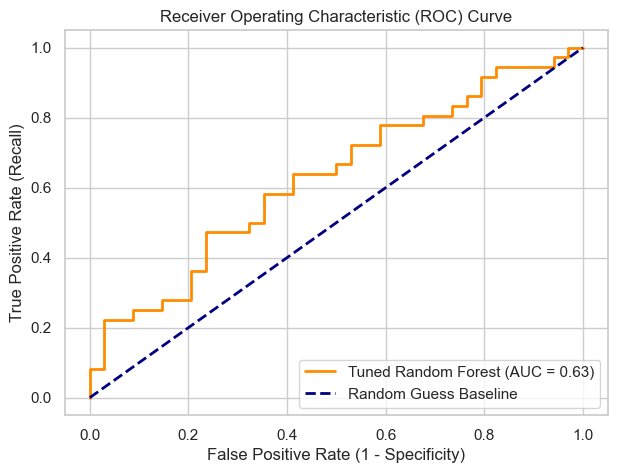

In [44]:


# ==========================================
# 14. ROC-AUC CURVE VISUALIZATION
# ==========================================
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Tuned Random Forest (AUC = {roc_auc_score(y_test, y_prob_tuned):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess Baseline')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [45]:
# ==========================================
# 15. SINGLE-SAMPLE INFERENCE / PREDICTION PIPELINE
# ==========================================
# Simulate a new incoming employee record
sample_employee = pd.DataFrame([{
    'Age': 28,
    'Department': 'Sales',
    'JobRole': 'Sales Rep',
    'MonthlyIncome': 35000,
    'DistanceFromHome': 25,
    'YearsAtCompany': 2,
    'JobSatisfaction': 1,
    'WorkLifeBalance': 1,
    'OverTime': 'Yes',
    'NumCompaniesWorked': 3
}])

# Align categorical columns with training feature set
sample_encoded = pd.get_dummies(sample_employee)
sample_encoded = sample_encoded.reindex(columns=X.columns, fill_value=0)

# Scale sample features and perform inference
sample_scaled = scaler.transform(sample_encoded)
churn_prediction = best_rf.predict(sample_scaled)[0]
churn_probability = best_rf.predict_proba(sample_scaled)[0][1]

print("\n--- Single Employee Attrition Prediction ---")
print(f"Attrition Risk Status: {'High Risk (Leave)' if churn_prediction == 1 else 'Low Risk (Stay)'}")
print(f"Probability of Attrition: {churn_probability:.2%}")


--- Single Employee Attrition Prediction ---
Attrition Risk Status: High Risk (Leave)
Probability of Attrition: 76.65%


In [46]:
import joblib

# Save both your trained model and your feature scaler
joblib.dump(model, 'attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler successfully saved!")

Model and Scaler successfully saved!
